In [1]:
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import xgboost as xgb
import lightgbm as lgb

In [2]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format) 

SEED = 42
np.random.seed(SEED)

PALETTE = {
    "primary":   "#3266ad",
    "secondary": "#e07b39",
    "tertiary":  "#2e9e6b",
    "danger":    "#c0392b",
    "light":     "#f4f4f4",
}

In [3]:
DATA_PATH="raw.csv"
df_raw=pd.read_csv(DATA_PATH)

df=df_raw.copy()

---
### **DATA CLEANING**

In [4]:
print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (77299, 11)

Column names:
['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']

First 5 rows:


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.0488,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.1185,Residential,3,Allowed,Yes,31.1046,Sunny
2,2,qp08bj,48,0:0,0.0271,Residential,1,Not Allowed,No,25.9193,Sunny
3,3,qp08gt,48,0:0,0.0033,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.0108,Residential,1,Not Allowed,No,10.8037,Rainy


In [5]:
print(df.dtypes)

Index              int64
geohash              str
day                int64
timestamp            str
demand           float64
RoadType             str
NumberofLanes      int64
LargeVehicles        str
Landmarks            str
Temperature      float64
Weather              str
dtype: object


In [6]:
n_dupes = df.duplicated(subset=["geohash", "day", "timestamp"]).sum() #confirm validation for primary data type
print(f"Dupes: {n_dupes}")

Dupes: 0


In [7]:
for col in df.columns:
    n_unique = df[col].nunique()
    example  = df[col].dropna().iloc[0]
    print(f"  {col:<20} {n_unique:>6}")

  Index                 77299
  geohash                1249
  day                       2
  timestamp                96
  demand                76715
  RoadType                  3
  NumberofLanes             5
  LargeVehicles             2
  Landmarks                 2
  Temperature           74804
  Weather                   4


so index unique, mostly unique demand and temperature hmm

In [8]:
missing = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "percentage null":   df.isnull().mean().mul(100).round(2),
    "dtype":      df.dtypes,
}).query("null_count > 0").sort_values("percentage null", ascending=False)

In [9]:
missing

,null_count,percentage null,dtype
Temperature,2495,3.2300,float64
Weather,797,1.0300,str
RoadType,600,0.7800,str


---
roadtype missing values can be mapped via geohash frequency mapping

In [10]:
geo_roadtype_mode = (
    df.groupby("geohash")["RoadType"]
    .agg(lambda x: x.mode()[0] if x.notna().any() else np.nan)
)

df["RoadType"] = df["RoadType"].fillna(df["geohash"].map(geo_roadtype_mode))

global_roadtype_mode = df["RoadType"].mode()[0]
df["RoadType"] = df["RoadType"].fillna(global_roadtype_mode)

print(f"nulls: {df['RoadType'].isnull().sum()}")
print(df["RoadType"].value_counts())

nulls: 0
RoadType
Residential    69789
Street          3917
Highway         3593
Name: count, dtype: int64


so heavily biased towards residential

---
weather is 4 types, small missingness, so just make it unknown

In [11]:
df["Weather"] = df["Weather"].fillna("Unknown")

print(f"nulls: {df['Weather'].isnull().sum()}")
print(df["Weather"].value_counts())

nulls: 0
Weather
Sunny      27717
Rainy      20824
Foggy      20243
Snowy       7718
Unknown      797
Name: count, dtype: int64


---
temperature left, temp is typicall ycontinuous, so connected to geohash and hour pairs? take median instead o fmean, fill with that?

In [12]:
df["_hour_tmp"] = df["timestamp"].str.split(":").str[0].astype(int)

geo_hour_temp_median = (
    df.groupby(["geohash", "_hour_tmp"])["Temperature"].median()
)

In [13]:
df["_hour_tmp"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [14]:
def fill_temperature(row):
    if pd.isnull(row["Temperature"]):
        key = (row["geohash"], row["_hour_tmp"])
        return geo_hour_temp_median.get(key, np.nan)
    return row["Temperature"]

In [15]:
df["Temperature"] = df.apply(fill_temperature, axis=1)

78 nulls left after this, so just use global median?

In [16]:
global_temp_median = df["Temperature"].median()
df["Temperature"] = df["Temperature"].fillna(global_temp_median)

In [17]:
df.drop(columns=["_hour_tmp"], inplace=True)

In [18]:
print(f"nulls: {df['Temperature'].isnull().sum()}")

nulls: 0


In [19]:
df.isnull().sum()

Index            0
geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64

---
### **EDA**

handling skewdness if i go ahead with lstm track, no point for xgboost

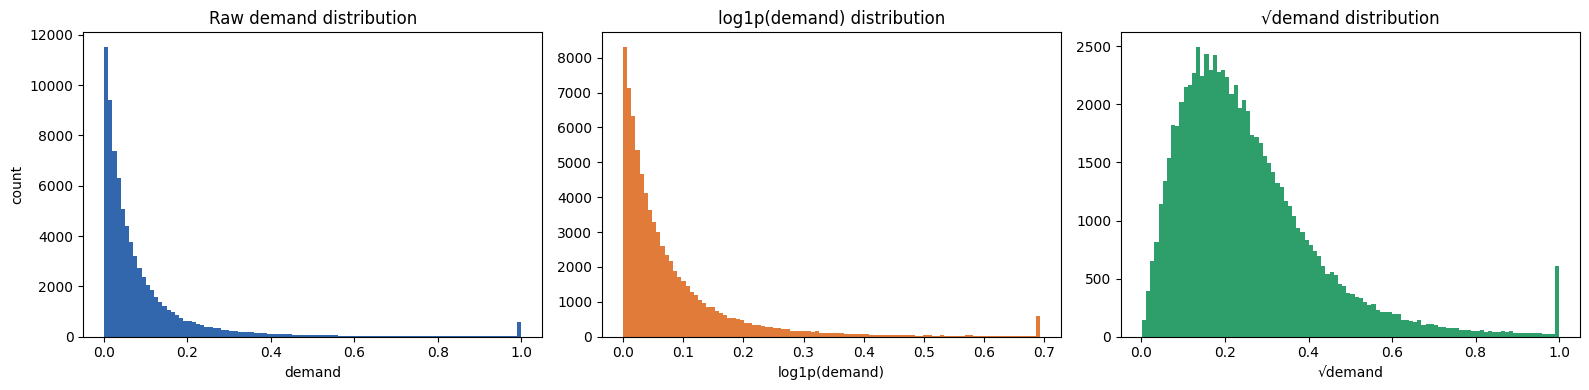

Skewness (raw):    3.7285
Skewness (log1p):  2.9651
Skewness (sqrt):   1.5752

count   77299.0000
mean        0.0939
std         0.1422
min         0.0000
25%         0.0182
50%         0.0478
75%         0.1086
max         1.0000
Name: demand, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["demand"], bins=100, color=PALETTE["primary"], edgecolor="none")
axes[0].set_title("Raw demand distribution")
axes[0].set_xlabel("demand")
axes[0].set_ylabel("count")

axes[1].hist(np.log1p(df["demand"]), bins=100, color=PALETTE["secondary"], edgecolor="none")
axes[1].set_title("log1p(demand) distribution")
axes[1].set_xlabel("log1p(demand)")

axes[2].hist(np.sqrt(df["demand"]), bins=100, color=PALETTE["tertiary"], edgecolor="none")
axes[2].set_title("√demand distribution")
axes[2].set_xlabel("√demand")

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Skewness (raw):    {df['demand'].skew():.4f}")
print(f"Skewness (log1p):  {np.log1p(df['demand']).skew():.4f}")
print(f"Skewness (sqrt):   {np.sqrt(df['demand']).skew():.4f}")
print()
print(df["demand"].describe())

holy skew

In [21]:
# Log1p distribution
print(f"Skewness (log1p):  {np.log1p(df['demand']).skew():.4f}")

Skewness (log1p):  2.9651


not much better

In [22]:
print(f"Skewness (sqrt):   {np.sqrt(df['demand']).skew():.4f}")

Skewness (sqrt):   1.5752


mildly better

Original Skewness: 3.7285
Yeo-Johnson Skewness: 0.4754
Quantile Normal Skewness: 0.6530


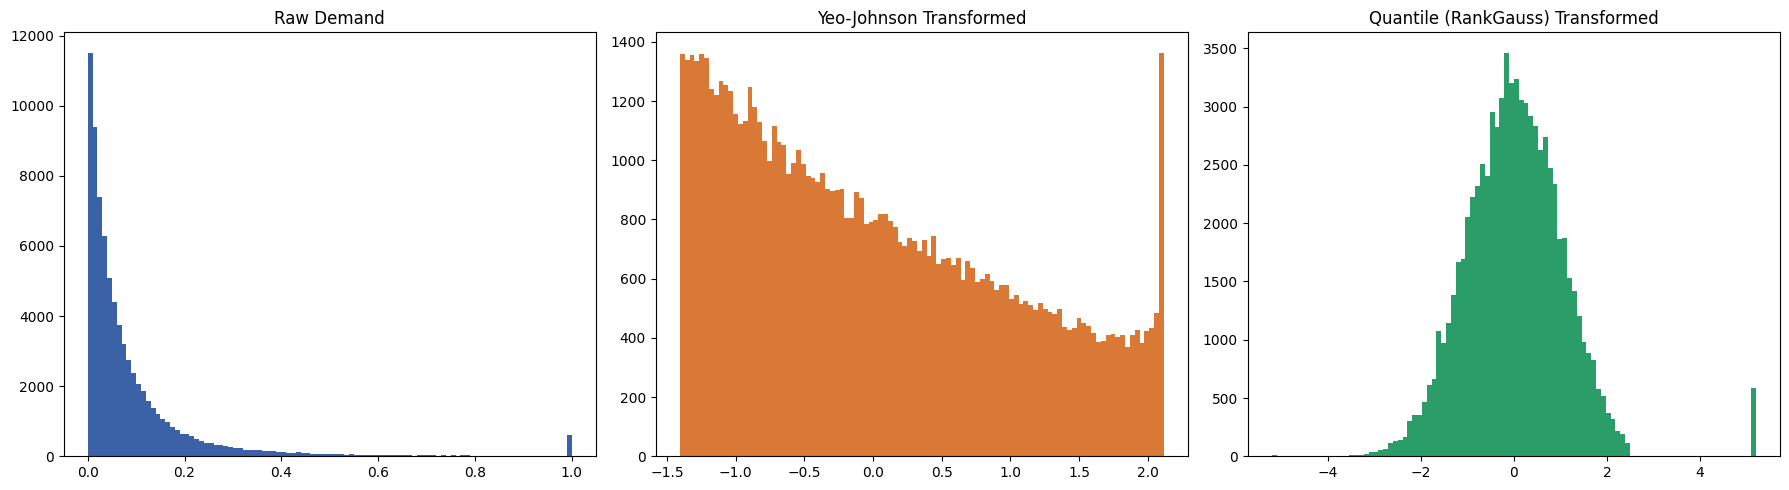

In [23]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

demand_data = df[['demand']]

pt_yeo = PowerTransformer(method='yeo-johnson', standardize=True)
df['demand_yeo_johnson'] = pt_yeo.fit_transform(demand_data)

qt_normal = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
df['demand_quantile_normal'] = qt_normal.fit_transform(demand_data)

print(f"Original Skewness: {df['demand'].skew():.4f}")
print(f"Yeo-Johnson Skewness: {df['demand_yeo_johnson'].skew():.4f}")
print(f"Quantile Normal Skewness: {df['demand_quantile_normal'].skew():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['demand'], bins=100, color='#3b62a6')
axes[0].set_title('Raw Demand')

axes[1].hist(df['demand_yeo_johnson'], bins=100, color='#d97935')
axes[1].set_title('Yeo-Johnson Transformed')

axes[2].hist(df['demand_quantile_normal'], bins=100, color='#2a9d68')
axes[2].set_title('Quantile (RankGauss) Transformed')

plt.tight_layout()
plt.show()

well yeo johnson wins

so use yeojohnson at end

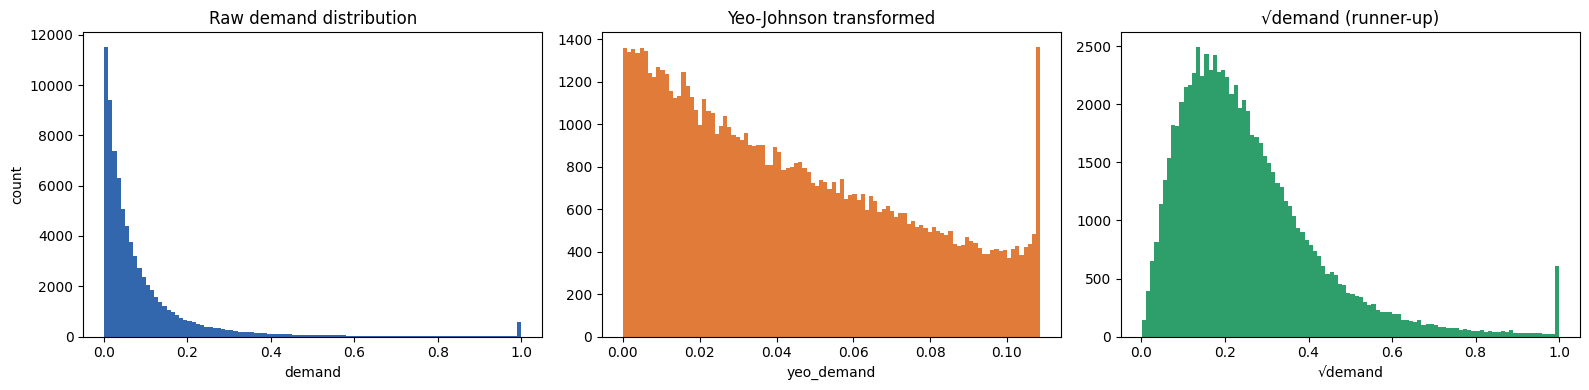

Skewness (raw):          3.7285
Skewness (Yeo-Johnson):  0.4754
Skewness (sqrt):         1.5752

count   77299.0000
mean        0.0939
std         0.1422
min         0.0000
25%         0.0182
50%         0.0478
75%         0.1086
max         1.0000
Name: demand, dtype: float64


In [24]:
pt_yeo_eda = PowerTransformer(method='yeo-johnson', standardize=False)
demand_yeo_eda = pt_yeo_eda.fit_transform(df[["demand"]]).flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
axes[0].hist(df["demand"], bins=100, color=PALETTE["primary"], edgecolor="none")
axes[0].set_title("Raw demand distribution")
axes[0].set_xlabel("demand")
axes[0].set_ylabel("count")

# Yeo-Johnson distribution
axes[1].hist(demand_yeo_eda, bins=100, color=PALETTE["secondary"], edgecolor="none")
axes[1].set_title("Yeo-Johnson transformed")
axes[1].set_xlabel("yeo_demand")

# Sqrt distribution (shown for comparison)
axes[2].hist(np.sqrt(df["demand"]), bins=100, color=PALETTE["tertiary"], edgecolor="none")
axes[2].set_title("√demand (runner-up)")
axes[2].set_xlabel("√demand")

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print key statistics
print(f"Skewness (raw):          {df['demand'].skew():.4f}")
print(f"Skewness (Yeo-Johnson):  {pd.Series(demand_yeo_eda).skew():.4f}")
print(f"Skewness (sqrt):         {np.sqrt(df['demand']).skew():.4f}")
print()
print(df["demand"].describe())

time structure


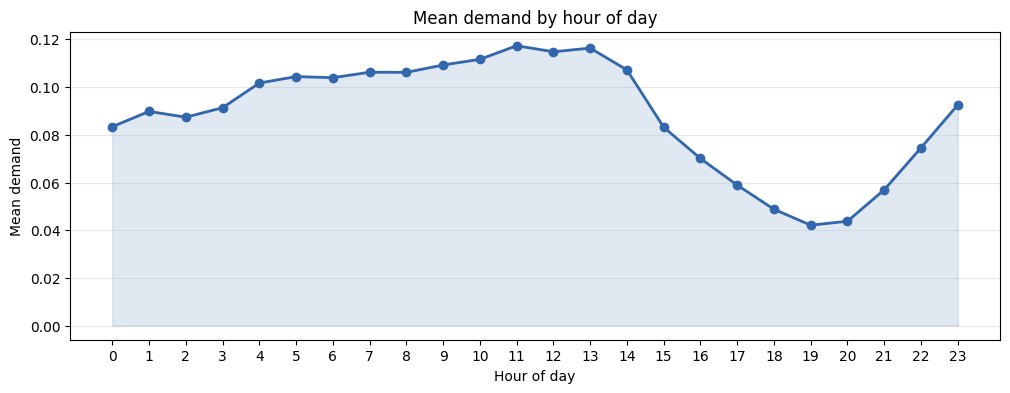

In [25]:
df["hour"]   = df["timestamp"].str.split(":").str[0].astype(int)
df["minute"] = df["timestamp"].str.split(":").str[1].astype(int)
df["time_minutes"] = df["hour"] * 60 + df["minute"]

hourly = df.groupby("hour")["demand"].mean()

plt.figure(figsize=(12, 4))
plt.plot(hourly.index, hourly.values, marker="o", color=PALETTE["primary"], lw=2)
plt.fill_between(hourly.index, hourly.values, alpha=0.15, color=PALETTE["primary"])
plt.xticks(range(0, 24))
plt.xlabel("Hour of day")
plt.ylabel("Mean demand")
plt.title("Mean demand by hour of day")
plt.grid(axis="y", alpha=0.3)
plt.savefig("hourly_demand.png", dpi=150, bbox_inches="tight")
plt.show()

rises slowly, peaks 10 am to 12pm, and stop, so no linear relationship, curve? encode time cyclically, make 11 pm connect backwards to midnight and so forth

In [26]:
print("Row count by day:")
print(df["day"].value_counts().sort_index())

print(f"\nCorrelation of 'day' with demand: {df['day'].corr(df['demand']):.4f}")

Row count by day:
day
48    69427
49     7872
Name: count, dtype: int64

Correlation of 'day' with demand: 0.0268


next to 0 basically, no corelation

rroad type should be a major info provider

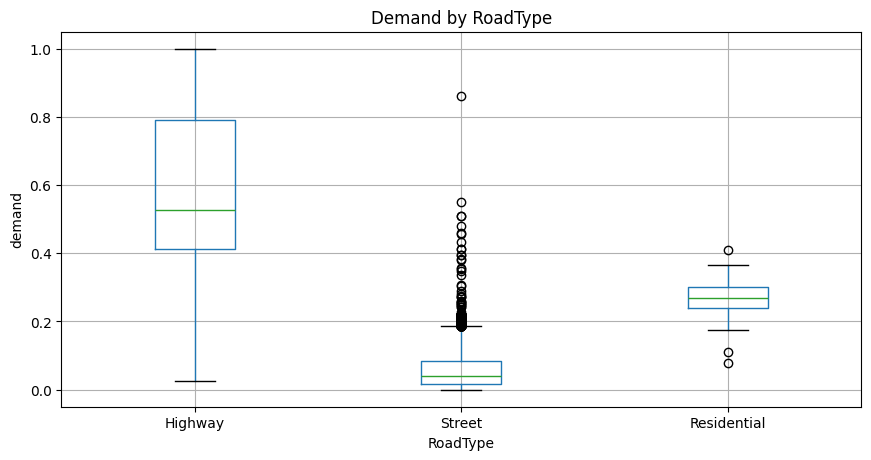

                 count   mean    std    min    25%    50%    75%    max
RoadType                                                               
Highway      3593.0000 0.6094 0.2306 0.0258 0.4134 0.5261 0.7899 1.0000
Residential 69789.0000 0.0573 0.0525 0.0000 0.0162 0.0405 0.0846 0.8607
Street       3917.0000 0.2731 0.0370 0.0784 0.2406 0.2681 0.3019 0.4101


In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
road_order = ["Highway", "Street", "Residential"]

df_plot = df[df["RoadType"].isin(road_order)]
df_plot.boxplot(column="demand", by="RoadType", ax=ax,
                positions=range(len(road_order)))

ax.set_xticklabels(road_order)
ax.set_title("Demand by RoadType")
ax.set_xlabel("RoadType")
ax.set_ylabel("demand")
plt.suptitle("")
plt.savefig("demand_by_roadtype.png", dpi=150, bbox_inches="tight")
plt.show()

# Print exact statistics
print(df.groupby("RoadType")["demand"].describe().round(4))

significant gap between highways and residential, no overlap in these groups, so either model learns boundary or oo we can try seperate models per type

In [28]:
print(df.groupby("NumberofLanes")["demand"].mean().round(4))

NumberofLanes
1   0.0881
2   0.0775
3   0.0779
4   0.6029
5   0.6076
Name: demand, dtype: float64


4 lane, 5 lane multicollinear honestly, same concpet?

In [29]:
for col in ["LargeVehicles", "Landmarks"]:
    print(f"\nMean demand by {col}:")
    print(df.groupby(col)["demand"].mean().round(4))


Mean demand by LargeVehicles:
LargeVehicles
Allowed       0.1319
Not Allowed   0.0740
Name: demand, dtype: float64

Mean demand by Landmarks:
Landmarks
No    0.0963
Yes   0.0928
Name: demand, dtype: float64


weather and temp

          mean    std  count
Weather                     
Foggy   0.0934 0.1411  20243
Rainy   0.0945 0.1416  20824
Snowy   0.0926 0.1383   7718
Sunny   0.0942 0.1444  27717
Unknown 0.0972 0.1458    797


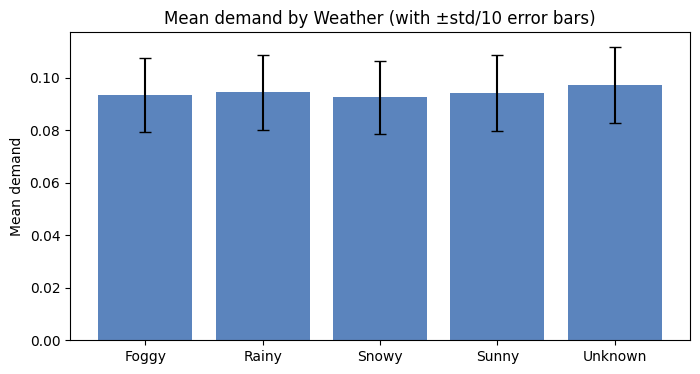

In [30]:
weather_demand = df.groupby("Weather")["demand"].agg(["mean", "std", "count"])
print(weather_demand.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
categories = weather_demand.index.tolist()
means      = weather_demand["mean"].values
stds       = weather_demand["std"].values

ax.bar(categories, means, yerr=stds/10, color=PALETTE["primary"],
       alpha=0.8, capsize=4)
ax.set_ylabel("Mean demand")
ax.set_title("Mean demand by Weather (with ±std/10 error bars)")
plt.savefig("demand_by_weather.png", dpi=150, bbox_inches="tight")
plt.show()

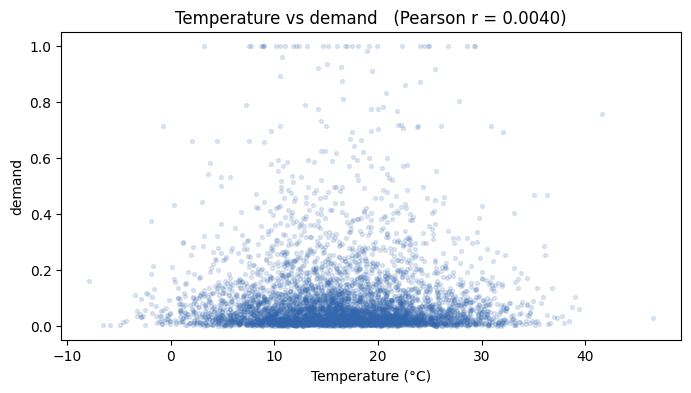

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
sample = df.sample(5000, random_state=SEED)  # subsample for readability
ax.scatter(sample["Temperature"], sample["demand"],
           alpha=0.15, s=8, color=PALETTE["primary"])
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("demand")
ax.set_title(f"Temperature vs demand   (Pearson r = {df['Temperature'].corr(df['demand']):.4f})")
plt.savefig("temperature_vs_demand.png", dpi=150, bbox_inches="tight")
plt.show()

pointless feature

now the real problem how important is the location

In [32]:
print(f"Unique geohashes: {df['geohash'].nunique()}")

geo_counts = df["geohash"].value_counts()
print(f"\nObservations per geohash:")
print(geo_counts.describe().round(1))

print(f"\nMost common count: {geo_counts.mode()[0]}")

Unique geohashes: 1249

Observations per geohash:
count   1249.0000
mean      61.9000
std       35.7000
min        1.0000
25%       30.0000
50%       71.0000
75%       94.0000
max      105.0000
Name: count, dtype: float64

Most common count: 105


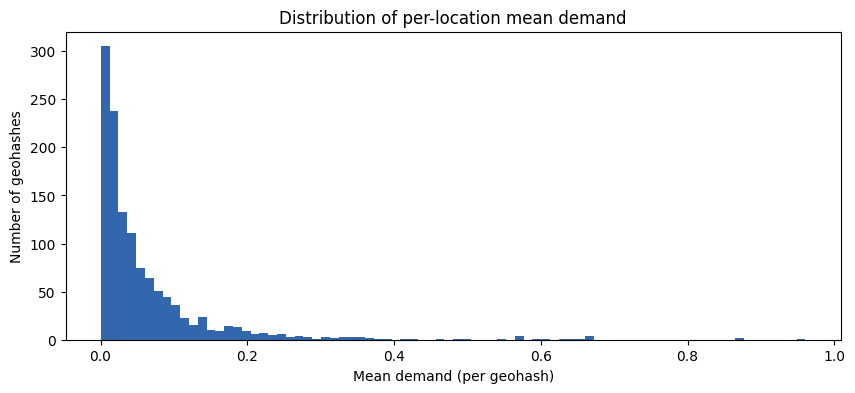


Geohash mean demand — std: 0.0999
Overall demand std: 0.1422


In [33]:
geo_demand = df.groupby("geohash")["demand"].mean()

plt.figure(figsize=(10, 4))
plt.hist(geo_demand, bins=80, color=PALETTE["primary"], edgecolor="none")
plt.xlabel("Mean demand (per geohash)")
plt.ylabel("Number of geohashes")
plt.title("Distribution of per-location mean demand")
plt.savefig("geo_demand_hist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nGeohash mean demand — std: {geo_demand.std():.4f}")
print(f"Overall demand std: {df['demand'].std():.4f}")

In [34]:
# Spatial autocorrelation: do nearby locations (same 5-char prefix) have similar demand?
df["geo5"] = df["geohash"].str[:5]
geo5_mean  = df.groupby("geo5")["demand"].mean()
df["geo5_demand_mean"] = df["geo5"].map(geo5_mean)

spatial_corr = df["demand"].corr(df["geo5_demand_mean"])
print(f"Correlation between demand and neighbour 5 char mean: {spatial_corr:.4f}")

Correlation between demand and neighbour 5 char mean: 0.3794


worth a feature

build autocorelation features, does past affect future? i.e demand just before predict demand now? actual time series?

In [35]:
df = df.sort_values(["geohash", "day", "time_minutes"]).reset_index(drop=True)

In [36]:
df["demand_lag1"] = df.groupby(["geohash", "day"])["demand"].shift(1)
df["demand_lag2"] = df.groupby(["geohash", "day"])["demand"].shift(2)
df["demand_lag4"] = df.groupby(["geohash", "day"])["demand"].shift(4)

lag1_corr = df["demand"].corr(df["demand_lag1"])
lag2_corr = df["demand"].corr(df["demand_lag2"])

print(f"Lag-1 autocorrelation: {lag1_corr:.4f}")
print(f"Lag-2 autocorrelation: {lag2_corr:.4f}")

Lag-1 autocorrelation: 0.9714
Lag-2 autocorrelation: 0.9559


oh dear, definitely a time series

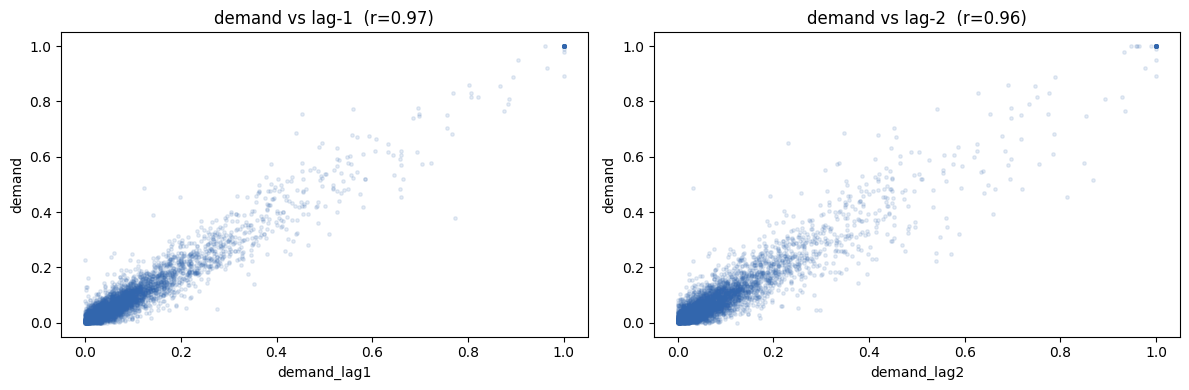

In [37]:
sample = df.dropna(subset=["demand_lag1"]).sample(5000, random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (lag_col, title) in zip(axes, [
    ("demand_lag1", f"demand vs lag-1  (r={lag1_corr:.2f})"),
    ("demand_lag2", f"demand vs lag-2  (r={lag2_corr:.2f})")
]):
    ax.scatter(sample[lag_col], sample["demand"],
               alpha=0.12, s=6, color=PALETTE["primary"])
    ax.set_xlabel(lag_col)
    ax.set_ylabel("demand")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("autocorrelation_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

yep a time series

---
## **Feature Engineering**

parse timestamps

In [38]:
df["hour"]         = df["timestamp"].str.split(":").str[0].astype(int)
df["minute"]       = df["timestamp"].str.split(":").str[1].astype(int)
df["time_minutes"] = df["hour"] * 60 + df["minute"]

In [39]:
print(f"time_minutes range: {df['time_minutes'].min()} to {df['time_minutes'].max()}")

time_minutes range: 0 to 1425


time encoding to make it cyclical i.e make time continuous

In [40]:
PERIOD = 1440

df["time_sin"] = np.sin(2 * np.pi * df["time_minutes"] / PERIOD)
df["time_cos"] = np.cos(2 * np.pi * df["time_minutes"] / PERIOD)

rolling window feature, combine what the lag features were sorta doing

In [41]:
df["demand_roll4_mean"] = (
    df.groupby(["geohash", "day"])["demand"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean())
)

df["demand_roll4_std"] = (
    df.groupby(["geohash", "day"])["demand"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=2).std())
)
df["demand_roll4_std"] = df["demand_roll4_std"].fillna(0)

In [42]:

print("Rolling features sample:")
print(df[["geohash", "day", "time_minutes", "demand",
          "demand_lag1", "demand_roll4_mean", "demand_roll4_std"]].head(12))

Rolling features sample:
   geohash  day  time_minutes  demand  demand_lag1  demand_roll4_mean  \
0   qp02yc   48            60  0.0054          NaN                NaN   
1   qp02yc   48           150  0.0129       0.0054             0.0054   
2   qp02yc   48           165  0.0260       0.0129             0.0092   
3   qp02yc   48           210  0.0264       0.0260             0.0148   
4   qp02yc   48           390  0.0084       0.0264             0.0177   
5   qp02yc   48           405  0.0208       0.0084             0.0184   
6   qp02yc   48           420  0.0049       0.0208             0.0204   
7   qp02yc   48           435  0.0271       0.0049             0.0151   
8   qp02yc   48           450  0.0048       0.0271             0.0153   
9   qp02yc   48           540  0.0174       0.0048             0.0144   
10  qp02yc   48           630  0.0468       0.0174             0.0135   
11  qp02yc   48           645  0.0212       0.0468             0.0240   

    demand_roll4_std  
0 

engineering a feature for neighbours, compute later inside train val split

In [43]:
df["geo5"] = df["geohash"].str[:5]

In [44]:
df["geo5"]

0        qp02y
1        qp02y
2        qp02y
3        qp02y
4        qp02y
         ...  
77294    qp0dn
77295    qp0dn
77296    qp0dn
77297    qp0dn
77298    qp0dn
Name: geo5, Length: 77299, dtype: str

encode geohash lmao because one hot deffinitely wont work, and boosted trees would handle it by itself, but i wanna try regression first

In [45]:
def target_encode(train_series, target_series, val_series=None, smoothing=10):
    """
    Encode a categorical column using smoothed target means from the training set.

    Parameters
    ----------
    train_series : pd.Series   — the categorical column in the training set
    target_series : pd.Series  — the target column in the training set (same index)
    val_series    : pd.Series  — the categorical column in the val/test set (optional)
    smoothing     : int        — strength of shrinkage towards global mean

    Returns
    -------
    train_encoded, val_encoded  — numeric arrays
    """
    global_mean = target_series.mean()

    # Per-category statistics from training data
    stats = (
        pd.DataFrame({"cat": train_series, "target": target_series})
        .groupby("cat")["target"]
        .agg(["mean", "count"])
    )
    stats["encoded"] = (
        (stats["count"] * stats["mean"] + smoothing * global_mean)
        / (stats["count"] + smoothing)
    )
    mapping = stats["encoded"].to_dict()

    train_encoded = train_series.map(mapping).fillna(global_mean)
    val_encoded   = val_series.map(mapping).fillna(global_mean) if val_series is not None else None

    return train_encoded, val_encoded


transform target using jeo johnson as well

In [46]:
from sklearn.preprocessing import PowerTransformer

pt_yeo = PowerTransformer(method='yeo-johnson', standardize=False)
df["yeo_demand"] = pt_yeo.fit_transform(df[["demand"]]).flatten()

In [47]:

print(f"demand — skewness: {df['demand'].skew():.4f}")
print(f"yeo_demand — skewness: {df['yeo_demand'].skew():.4f}")

demand — skewness: 3.7285
yeo_demand — skewness: 0.4754


---
## **TRAIN VALIDATION SPLIT YAYY**

timeseries, so cant randomly shuffle, so split by time? so have time zones, and we already have seperations by day 48 and day 49 in a premade train test split of 90-10 (flipkart did you do this intentionally)

In [48]:
df_train = df[df["day"] == 48].copy()
df_val   = df[df["day"] == 49].copy()

pt_yeo = PowerTransformer(method='yeo-johnson', standardize=False)
df_train["yeo_demand"] = pt_yeo.fit_transform(df_train[["demand"]]).flatten()

df_val["yeo_demand"] = pt_yeo.transform(df_val[["demand"]]).flatten()

In [49]:

print(f"Train yeo_demand — skewness: {df_train['yeo_demand'].skew():.4f}")
print(f"Val   yeo_demand — skewness: {df_val['yeo_demand'].skew():.4f}")

print(f"Training rows:   {len(df_train):,}  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validation rows: {len(df_val):,}  ({len(df_val)/len(df)*100:.1f}%)")

Train yeo_demand — skewness: 0.4803
Val   yeo_demand — skewness: 0.3136
Training rows:   69,427  (89.8%)
Validation rows: 7,872  (10.2%)


removing lag where you cant have lag features lol

In [50]:
lag_cols = ["demand_lag1", "demand_lag2", "demand_lag4"]

n_before = len(df_train)
df_train = df_train.dropna(subset=lag_cols)
print(f"Training rows dropped (no lag): {n_before - len(df_train):,}")

n_before = len(df_val)
df_val = df_val.dropna(subset=lag_cols)
print(f"Validation rows dropped (no lag): {n_before - len(df_val):,}")

Training rows dropped (no lag): 4,745
Validation rows dropped (no lag): 3,987


apply target encodings for geohash, compute from training set, apply to train and validation

In [51]:
df_train["geohash_encoded"], df_val["geohash_encoded"] = target_encode(
    train_series  = df_train["geohash"],
    target_series = df_train["demand"],   # use raw demand for the encoding mean
    val_series    = df_val["geohash"],
    smoothing     = 15,
)

In [52]:
print("Geohash target encoding applied.")
print(f"Train geohash_encoded — mean: {df_train['geohash_encoded'].mean():.4f}")

Geohash target encoding applied.
Train geohash_encoded — mean: 0.0995


spatial neighbour feature, compute mean demand from training data

In [53]:
geo5_time_mean = (
    df_train.groupby(["geo5", "time_minutes"])["demand"]
    .mean()
    .rename("geo5_time_demand_mean")
    .reset_index()
)

df_train = df_train.merge(geo5_time_mean, on=["geo5", "time_minutes"], how="left")
df_val   = df_val.merge(geo5_time_mean, on=["geo5", "time_minutes"], how="left")

global_demand_mean = df_train["demand"].mean()
df_train["geo5_time_demand_mean"] = df_train["geo5_time_demand_mean"].fillna(global_demand_mean)
df_val["geo5_time_demand_mean"]   = df_val["geo5_time_demand_mean"].fillna(global_demand_mean)

encode numerically, binary columns 0/1 mapping, road type gets one-hot

In [54]:
df_train["LargeVehicles_enc"] = (df_train["LargeVehicles"] == "Allowed").astype(int)
df_val["LargeVehicles_enc"]   = (df_val["LargeVehicles"]   == "Allowed").astype(int)

df_train["Landmarks_enc"] = (df_train["Landmarks"] == "Yes").astype(int)
df_val["Landmarks_enc"]   = (df_val["Landmarks"]   == "Yes").astype(int)

df_train = pd.get_dummies(df_train, columns=["RoadType"], drop_first=True)
df_val   = pd.get_dummies(df_val,   columns=["RoadType"], drop_first=True)

for col in df_train.columns:
    if col not in df_val.columns:
        df_val[col] = 0

df_train = pd.get_dummies(df_train, columns=["Weather"], drop_first=True)
df_val   = pd.get_dummies(df_val,   columns=["Weather"], drop_first=True)

for col in df_train.columns:
    if col not in df_val.columns:
        df_val[col] = 0


final features list

In [55]:
FEATURES = [
    "time_sin", "time_cos", "time_minutes", "hour",
    "NumberofLanes", "LargeVehicles_enc", "Landmarks_enc",
    *[c for c in df_train.columns if c.startswith("RoadType_")],
    *[c for c in df_train.columns if c.startswith("Weather_")],
    "Temperature",
    "geohash_encoded", "geo5_time_demand_mean",
]

In [56]:
missing_features = [f for f in FEATURES if f not in df_train.columns]
assert len(missing_features) == 0, f"Missing features: {missing_features}"

In [57]:
TARGET      = "yeo_demand"
TARGET_RAW  = "demand"

X_train = df_train[FEATURES]
y_train = df_train[TARGET]

X_val   = df_val[FEATURES]
y_val   = df_val[TARGET_RAW]

print(f"Training matrix:   {X_train.shape}")
print(f"Validation matrix: {X_val.shape}")
print(f"\nFeature list ({len(FEATURES)} features):")
for f in FEATURES:
    print(f"  {f}")

Training matrix:   (64682, 16)
Validation matrix: (3885, 16)

Feature list (16 features):
  time_sin
  time_cos
  time_minutes
  hour
  NumberofLanes
  LargeVehicles_enc
  Landmarks_enc
  RoadType_Residential
  RoadType_Street
  Weather_Rainy
  Weather_Snowy
  Weather_Sunny
  Weather_Unknown
  Temperature
  geohash_encoded
  geo5_time_demand_mean


---
## Baseline **LINEAR REGRESSION**

In [58]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_val_scaled   = scaler.transform(X_val)      

ridge = Ridge(alpha=10.0)
ridge.fit(X_train_scaled, y_train)

y_pred_yeo_train = ridge.predict(X_train_scaled)
y_pred_yeo_val   = ridge.predict(X_val_scaled)

y_pred_yeo_train = np.clip(y_pred_yeo_train, y_train.min(), y_train.max())
y_pred_yeo_val   = np.clip(y_pred_yeo_val, y_train.min(), y_train.max())

y_pred_train = pt_yeo.inverse_transform(y_pred_yeo_train.reshape(-1, 1)).flatten()
y_pred_val   = pt_yeo.inverse_transform(y_pred_yeo_val.reshape(-1, 1)).flatten()

y_pred_train = np.clip(y_pred_train, 0, 1)
y_pred_val   = np.clip(y_pred_val,   0, 1)

# Evaluation metric from the competition: max(0, 100 * R²)
def competition_score(actual, predicted):
    return max(0, 100 * r2_score(actual, predicted))

score_train = competition_score(df_train[TARGET_RAW], y_pred_train)
score_val   = competition_score(y_val, y_pred_val)

found nan's when training regression, lets diagonise (found it lag 4 lmao. and then in inversions)

In [59]:
print("=" * 40)
print("  BASELINE — Ridge Regression")
print("=" * 40)
print(f"  Train score: {score_train:.2f}")
print(f"  Val score:   {score_val:.2f}")

  BASELINE — Ridge Regression
  Train score: 47.37
  Val score:   35.18


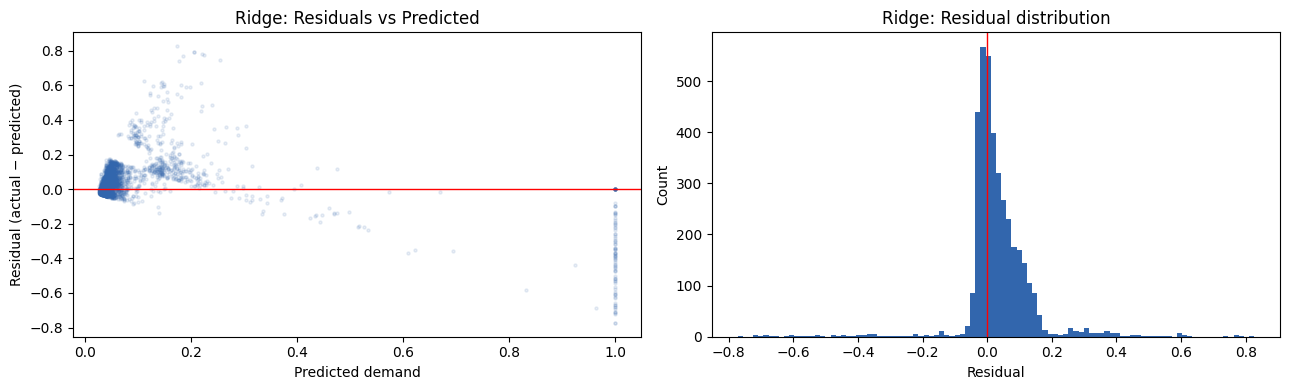

In [60]:
residuals = y_val.values - y_pred_val

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred_val, residuals, alpha=0.1, s=5, color=PALETTE["primary"])
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Predicted demand")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Ridge: Residuals vs Predicted")

axes[1].hist(residuals, bins=100, color=PALETTE["primary"], edgecolor="none")
axes[1].axvline(0, color="red", lw=1)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Ridge: Residual distribution")

plt.tight_layout()
plt.savefig("ridge_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

In [61]:
coef_df = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": ridge.coef_,
}).sort_values("coefficient", key=abs, ascending=False)

print("Top 15 most influential features (by absolute coefficient):")
print(coef_df.head(15).to_string(index=False))

Top 15 most influential features (by absolute coefficient):
              feature  coefficient
      geohash_encoded       0.0146
geo5_time_demand_mean       0.0056
      RoadType_Street       0.0052
             time_sin       0.0050
 RoadType_Residential      -0.0029
             time_cos      -0.0013
                 hour       0.0009
         time_minutes      -0.0007
        NumberofLanes       0.0006
        Landmarks_enc      -0.0003
    LargeVehicles_enc      -0.0002
        Weather_Rainy       0.0001
        Weather_Snowy       0.0001
          Temperature       0.0001
      Weather_Unknown      -0.0000


---
## **XGBOOST**

In [62]:
xgb_model = xgb.XGBRegressor(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = SEED,
    n_jobs            = -1,
    early_stopping_rounds = 50,
    eval_metric       = "rmse",
)

In [63]:
xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_val, df_val[TARGET])],
    verbose  = 100,
)

[0]	validation_0-rmse:0.03007
[100]	validation_0-rmse:0.01752
[108]	validation_0-rmse:0.01753


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [64]:
y_pred_xgb_train = np.clip(
    pt_yeo.inverse_transform(xgb_model.predict(X_train).reshape(-1, 1)).flatten(), 0, 1
)
y_pred_xgb_val = np.clip(
    pt_yeo.inverse_transform(xgb_model.predict(X_val).reshape(-1, 1)).flatten(), 0, 1
)

score_xgb_train = competition_score(df_train[TARGET_RAW], y_pred_xgb_train)
score_xgb_val   = competition_score(y_val, y_pred_xgb_val)

In [65]:
print("=" * 40)
print("  MODEL 1 — XGBoost")
print("=" * 40)
print(f"  Train score: {score_xgb_train:.2f}")
print(f"  Val score:   {score_xgb_val:.2f}")

  MODEL 1 — XGBoost
  Train score: 71.16
  Val score:   66.77


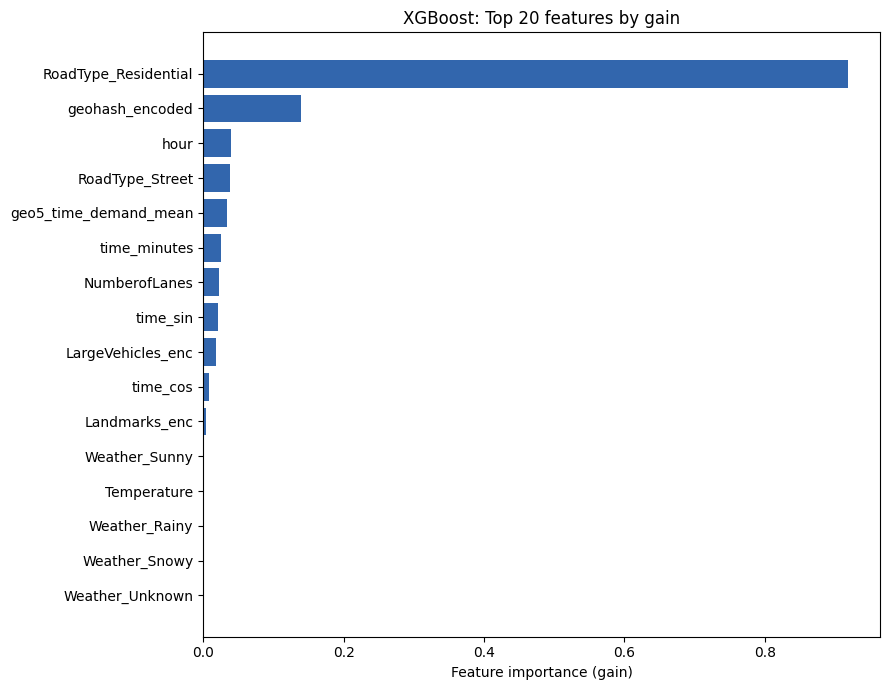

In [66]:
importance = xgb_model.get_booster().get_score(importance_type="gain")
importance_df = (
    pd.DataFrame.from_dict(importance, orient="index", columns=["gain"])
    .sort_values("gain", ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df.index, importance_df["gain"], color=PALETTE["primary"])
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGBoost: Top 20 features by gain")
plt.tight_layout()
plt.savefig("xgb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

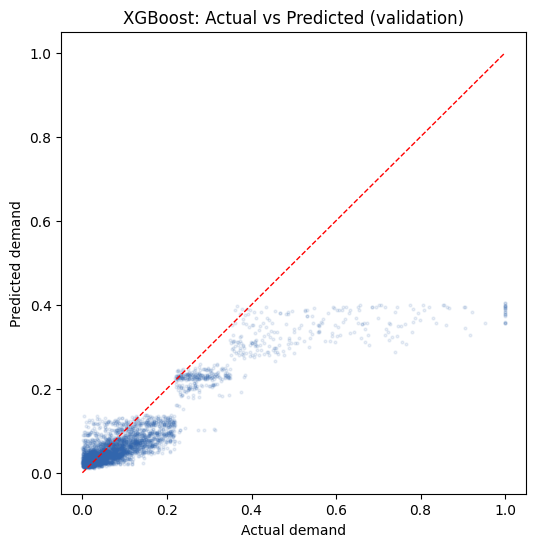

In [67]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, y_pred_xgb_val, alpha=0.1, s=4, color=PALETTE["primary"])
ax.plot([0, 1], [0, 1], "r--", lw=1)
ax.set_xlabel("Actual demand")
ax.set_ylabel("Predicted demand")
ax.set_title("XGBoost: Actual vs Predicted (validation)")
plt.savefig("xgb_actual_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()

much better, already closer to 100

---
## **LIGHTGBM**

In [68]:
FEATURES_LGB = FEATURES.copy()

df_train["geohash_cat"] = df_train["geohash"].astype("category")
df_val["geohash_cat"]   = df_val["geohash"].astype("category")

known_cats = df_train["geohash_cat"].cat.categories
df_val["geohash_cat"] = pd.Categorical(df_val["geohash_cat"], categories=known_cats)

FEATURES_LGB_NATIVE = FEATURES + ["geohash_cat"]
FEATURES_LGB_NATIVE = [f for f in FEATURES_LGB_NATIVE if f != "geohash_encoded"]

X_train_lgb = df_train[FEATURES_LGB_NATIVE]
X_val_lgb   = df_val[FEATURES_LGB_NATIVE]

In [69]:
lgb_train_data = lgb.Dataset(
    X_train_lgb, label=y_train,
    categorical_feature=["geohash_cat"],
    free_raw_data=False,
)

lgb_val_data = lgb.Dataset(
    X_val_lgb, label=df_val[TARGET],
    categorical_feature=["geohash_cat"],
    reference=lgb_train_data,
    free_raw_data=False,
)

In [70]:
lgb_params = {
    "objective":        "regression",
    "metric":           "rmse",
    "learning_rate":    0.05,
    "num_leaves":       127,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "reg_alpha":        0.1,
    "reg_lambda":       1.0, 
    "verbose":          -1,
    "seed":             SEED,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100),
]


In [71]:
lgb_model = lgb.train(
    params            = lgb_params,
    train_set         = lgb_train_data,
    num_boost_round   = 1000,
    valid_sets        = [lgb_val_data],
    callbacks         = callbacks,
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.0165643
Early stopping, best iteration is:
[59]	valid_0's rmse: 0.0163731


In [72]:
print(f"\nBest iteration: {lgb_model.best_iteration}")


Best iteration: 59


In [73]:
y_pred_lgb_train = np.clip(
    pt_yeo.inverse_transform(lgb_model.predict(X_train_lgb).reshape(-1, 1)).flatten(), 0, 1
)
y_pred_lgb_val = np.clip(
    pt_yeo.inverse_transform(lgb_model.predict(X_val_lgb).reshape(-1, 1)).flatten(), 0, 1
)

score_lgb_train = competition_score(df_train[TARGET_RAW], y_pred_lgb_train)
score_lgb_val   = competition_score(y_val, y_pred_lgb_val)

In [74]:
print("=" * 40)
print("  MODEL 2 — LightGBM")
print("=" * 40)
print(f"  Train score: {score_lgb_train:.2f}")
print(f"  Val score:   {score_lgb_val:.2f}")

  MODEL 2 — LightGBM
  Train score: 72.73
  Val score:   70.59


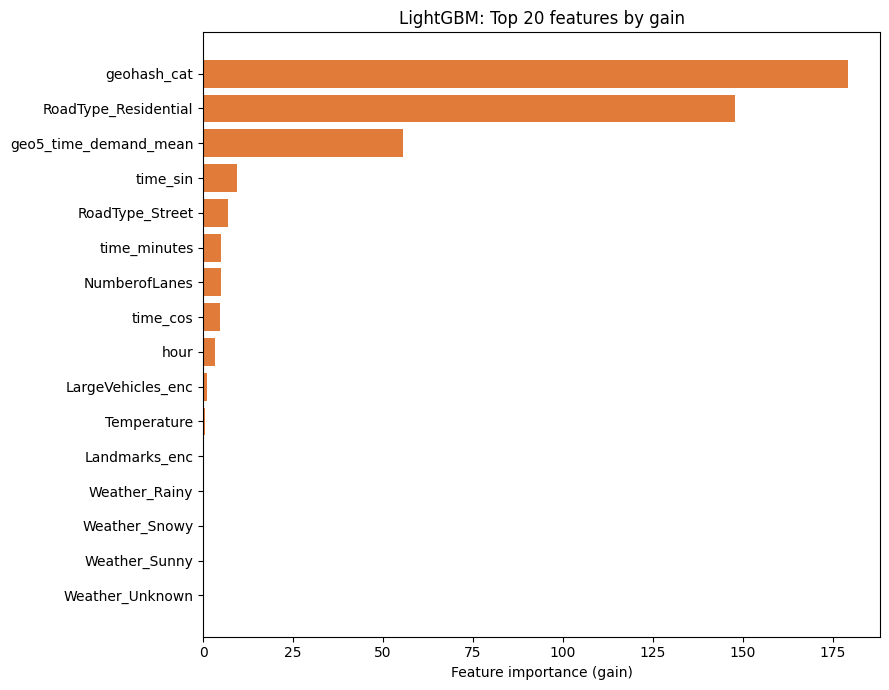

In [75]:
lgb_importance = pd.DataFrame({
    "feature": lgb_model.feature_name(),
    "gain":    lgb_model.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(lgb_importance["feature"], lgb_importance["gain"], color=PALETTE["secondary"])
ax.set_xlabel("Feature importance (gain)")
ax.set_title("LightGBM: Top 20 features by gain")
plt.tight_layout()
plt.savefig("lgb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## **PER ROAD TYPE LGBM**
Split into three models for each road type

In [76]:
road_types = ["Highway", "Residential", "Street"]
models_per_road = {}
results_per_road = {}

for road_type in road_types:
    print(f"\n{'='*50}")
    print(f"  Training model for: {road_type}")
    print(f"{'='*50}")

    res_train = df_train.get("RoadType_Residential", pd.Series(0, index=df_train.index)).astype(bool)
    str_train = df_train.get("RoadType_Street", pd.Series(0, index=df_train.index)).astype(bool)
    
    res_val = df_val.get("RoadType_Residential", pd.Series(0, index=df_val.index)).astype(bool)
    str_val = df_val.get("RoadType_Street", pd.Series(0, index=df_val.index)).astype(bool)

    if road_type == "Residential":
        mask_train = res_train
        mask_val   = res_val

    elif road_type == "Street":
        mask_train = str_train
        mask_val   = str_val

    elif road_type == "Highway":
        mask_train = ~(res_train | str_train)
        mask_val   = ~(res_val | str_val)

    sub_train = df_train[mask_train]
    sub_val   = df_val[mask_val]
    print(f"  Train rows: {len(sub_train):,}  |  Val rows: {len(sub_val):,}")

    if len(sub_train) < 50 or len(sub_val) < 10:
        print(f"  Skipping — insufficient data.")
        continue

    lgb_sub_train = lgb.Dataset(
        sub_train[FEATURES_LGB_NATIVE], label=sub_train[TARGET],
        categorical_feature=["geohash_cat"], free_raw_data=False,
    )
    lgb_sub_val = lgb.Dataset(
        sub_val[FEATURES_LGB_NATIVE], label=sub_val[TARGET],
        categorical_feature=["geohash_cat"],
        reference=lgb_sub_train, free_raw_data=False,
    )

    model = lgb.train(
        params          = lgb_params,
        train_set       = lgb_sub_train,
        num_boost_round = 1000,
        valid_sets      = [lgb_sub_val],
        callbacks       = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=200),
        ],
    )

    models_per_road[road_type] = model

    y_pred_sub = np.clip(
        pt_yeo.inverse_transform(model.predict(sub_val[FEATURES_LGB_NATIVE]).reshape(-1, 1)).flatten(), 0, 1
    )
    score = competition_score(sub_val[TARGET_RAW], y_pred_sub)
    results_per_road[road_type] = score
    print(f"  Val score ({road_type}): {score:.2f}")


  Training model for: Highway
  Train rows: 3,100  |  Val rows: 259
  Val score (Highway): 0.00

  Training model for: Residential
  Train rows: 58,237  |  Val rows: 3,347
  Val score (Residential): 41.25

  Training model for: Street
  Train rows: 3,345  |  Val rows: 279
  Val score (Street): 0.00


In [77]:
y_pred_combined = np.zeros(len(df_val))

res_val_mask = df_val.get("RoadType_Residential", pd.Series(0, index=df_val.index)).astype(bool)
str_val_mask = df_val.get("RoadType_Street", pd.Series(0, index=df_val.index)).astype(bool)
highway_val_mask = ~(res_val_mask | str_val_mask)

if "Highway" in models_per_road:
    idx = df_val.index[highway_val_mask]
    y_pred_combined[highway_val_mask.values] = np.clip(
        pt_yeo.inverse_transform(models_per_road["Highway"].predict(df_val.loc[idx, FEATURES_LGB_NATIVE]).reshape(-1, 1)).flatten(), 0, 1
    )

if "Street" in models_per_road:
    idx = df_val.index[str_val_mask]
    y_pred_combined[str_val_mask.values] = np.clip(
        pt_yeo.inverse_transform(models_per_road["Street"].predict(df_val.loc[idx, FEATURES_LGB_NATIVE]).reshape(-1, 1)).flatten(), 0, 1
    )

if "Residential" in models_per_road:
    idx = df_val.index[res_val_mask]
    y_pred_combined[res_val_mask.values] = np.clip(
        pt_yeo.inverse_transform(models_per_road["Residential"].predict(df_val.loc[idx, FEATURES_LGB_NATIVE]).reshape(-1, 1)).flatten(), 0, 1
    )

score_combined = competition_score(y_val, y_pred_combined)

In [78]:
print("=" * 40)
print("  MODEL 3 — Per-RoadType LightGBM")
print("=" * 40)
for road_type, score in results_per_road.items():
    print(f"  Val score ({road_type:<15}): {score:.2f}")
print(f"\n  Combined val score: {score_combined:.2f}")

  MODEL 3 — Per-RoadType LightGBM
  Val score (Highway        ): 0.00
  Val score (Residential    ): 41.25
  Val score (Street         ): 0.00

  Combined val score: 79.81


---
## **OVERALL RESULTS**

In [79]:
results_summary = pd.DataFrame([
    {"Model": "Baseline (Ridge)",         "Val Score": score_val,       "Notes": "Simple linear, log1p target, all features"},
    {"Model": "XGBoost",                  "Val Score": score_xgb_val,   "Notes": "Tree ensemble, lag features, early stopping"},
    {"Model": "LightGBM",                 "Val Score": score_lgb_val,   "Notes": "LGB native categoricals, leaf-wise growth"},
    {"Model": "Per-RoadType LightGBM",    "Val Score": score_combined,  "Notes": "Separate model per road type"},
]).sort_values("Val Score", ascending=False)

In [80]:
print(results_summary.to_string(index=False))

                Model  Val Score                                       Notes
Per-RoadType LightGBM    79.8144                Separate model per road type
             LightGBM    70.5920   LGB native categoricals, leaf-wise growth
              XGBoost    66.7660 Tree ensemble, lag features, early stopping
     Baseline (Ridge)    35.1800   Simple linear, log1p target, all features


---
### LSTM, because a net always works eventually hehe, and i mean it is timeseries, so sequential which might help

In [81]:
ts_per_geo_day = df_train.groupby(["geohash", "day"])["time_minutes"].count()
print("Timestamps per (geohash, day):")
print(ts_per_geo_day.describe().round(1))

Timestamps per (geohash, day):
count   1121.0000
mean      57.7000
std       28.7000
min        1.0000
25%       35.0000
50%       64.0000
75%       84.0000
max       92.0000
Name: time_minutes, dtype: float64


In [82]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEQ_LEN    = 8
HIDDEN_DIM = 64
NUM_LAYERS = 2
DROPOUT    = 0.2
BATCH_SIZE = 512
LR         = 1e-3
EPOCHS     = 30
PATIENCE   = 5

In [83]:
LSTM_FEATURES = [
    "demand",
    "time_sin", "time_cos",
    "NumberofLanes",
    "LargeVehicles_enc",
    "Landmarks_enc",
    "Temperature",
    "geohash_encoded",
    "geo5_time_demand_mean",
    *[c for c in df_train.columns if c.startswith("RoadType_")],
    *[c for c in df_train.columns if c.startswith("Weather_")],
]

In [84]:
missing = [f for f in LSTM_FEATURES if f not in df_train.columns]
assert len(missing) == 0, f"Missing LSTM features: {missing}"

In [85]:
INPUT_DIM = len(LSTM_FEATURES)

In [86]:
from sklearn.preprocessing import StandardScaler

feat_scaler = StandardScaler()
feat_scaler.fit(df_train[LSTM_FEATURES])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [87]:
class TrafficSequenceDataset(Dataset):
    """
    Converts a DataFrame of traffic observations into sliding-window sequences
    for LSTM training.

    For each (geohash, day) group sorted by time:
      - Slide a window of SEQ_LEN over the observations
      - Input X: SEQ_LEN × INPUT_DIM feature matrix
      - Label y: demand value at the next timestep (in log1p space)
    """

    def __init__(self, df, features, scaler, seq_len, fit_scaler=False):
        self.sequences = []
        self.labels    = []

        feat_array = scaler.transform(df[features].values)
        demand_yeo = pt_yeo.transform(df[["demand"]]).flatten() 

        groups = df.groupby(["geohash", "day"], sort=False).indices

        for (geo, day), idx in groups.items():
            idx_sorted = idx[np.argsort(df.iloc[idx]["time_minutes"].values)]
            feat_seq   = feat_array[idx_sorted]    # shape: (T, INPUT_DIM)
            label_seq  = demand_yeo[idx_sorted]    # shape: (T,)

            T = len(feat_seq)
            if T <= seq_len:
                continue

            # Slide the window
            for start in range(T - seq_len):
                x = feat_seq[start : start + seq_len]
                y = label_seq[start + seq_len]
                self.sequences.append(x)
                self.labels.append(y)

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.labels    = np.array(self.labels,    dtype=np.float32)
        print(f"Dataset built: {len(self.sequences):,} sequences")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx]),
            torch.tensor(self.labels[idx]),
        )

In [88]:
train_dataset = TrafficSequenceDataset(df_train, LSTM_FEATURES, feat_scaler, SEQ_LEN)
val_dataset   = TrafficSequenceDataset(df_val,   LSTM_FEATURES, feat_scaler, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Dataset built: 56,045 sequences
Dataset built: 0 sequences


In [89]:
class TrafficLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size   = input_dim,
            hidden_size  = hidden_dim,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0.0,
            batch_first  = True,
        )
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)

        last_hidden = h_n[-1]               # (batch, hidden_dim) — top layer, last step
        out = self.dropout(last_hidden)
        out = self.head(out)                # (batch, 1)
        return out.squeeze(1)               # (batch,) — remove the trailing 1

In [90]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model_lstm = TrafficLSTM(
    input_dim  = INPUT_DIM,
    hidden_dim = HIDDEN_DIM,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

criterion = nn.MSELoss()
optimiser = torch.optim.Adam(model_lstm.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode="min", factor=0.5, patience=3
)

Training on: cuda
Trainable parameters: 54,081


In [91]:
def run_epoch(model, loader, criterion, optimiser=None, device="cpu"):
    """Run one full pass through the data. If optimiser is given, update weights."""
    is_training = optimiser is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    n_batches  = 0

    with torch.set_grad_enabled(is_training):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)

            if is_training:
                optimiser.zero_grad()
                loss.backward()
                # Gradient clipping: prevents exploding gradients, a common
                # pathology in RNNs when sequences have very large values
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimiser.step()

            total_loss += loss.item()
            n_batches  += 1

    return total_loss / n_batches

In [92]:
best_val_loss  = float("inf")
patience_count = 0
history        = {"train_loss": [], "val_loss": []}

build lstm lookback

In [93]:
lstm_lookback = df_train.groupby("geohash").tail(SEQ_LEN).copy()

lstm_lookback["day"] = 49

df_val_lstm = pd.concat([lstm_lookback, df_val], ignore_index=True)

df_val_lstm = df_val_lstm.sort_values(["geohash", "day", "time_minutes"]).reset_index(drop=True)

val_dataset = TrafficSequenceDataset(df_val_lstm, LSTM_FEATURES, feat_scaler, SEQ_LEN)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nNew validation batches: {len(val_loader)}")

Dataset built: 3,863 sequences

New validation batches: 8


In [94]:
print(f"\n{'Epoch':>6}  {'Train Loss':>12}  {'Val Loss':>10}  {'LR':>10}")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model_lstm, train_loader, criterion, optimiser, device)
    val_loss   = run_epoch(model_lstm, val_loader,   criterion, None,      device)

    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    current_lr = optimiser.param_groups[0]["lr"]
    print(f"{epoch:>6}  {train_loss:>12.6f}  {val_loss:>10.6f}  {current_lr:>10.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_lstm.state_dict(), "best_lstm.pt")  # checkpoint
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val loss: {best_val_loss:.6f}")
            break


 Epoch    Train Loss    Val Loss          LR
--------------------------------------------------
     1      0.000576    0.000189    1.00e-03
     2      0.000214    0.000172    1.00e-03
     3      0.000180    0.000165    1.00e-03
     4      0.000167    0.000157    1.00e-03
     5      0.000159    0.000160    1.00e-03
     6      0.000152    0.000147    1.00e-03
     7      0.000147    0.000143    1.00e-03
     8      0.000143    0.000141    1.00e-03
     9      0.000140    0.000139    1.00e-03
    10      0.000138    0.000138    1.00e-03
    11      0.000135    0.000133    1.00e-03
    12      0.000133    0.000132    1.00e-03
    13      0.000131    0.000134    1.00e-03
    14      0.000130    0.000131    1.00e-03
    15      0.000129    0.000128    1.00e-03
    16      0.000128    0.000129    1.00e-03
    17      0.000127    0.000139    1.00e-03
    18      0.000128    0.000129    1.00e-03
    19      0.000127    0.000127    1.00e-03
    20      0.000126    0.000128    1.00e-03
   

In [95]:
model_lstm.load_state_dict(torch.load("best_lstm.pt"))
print("Best model weights restored.")

Best model weights restored.


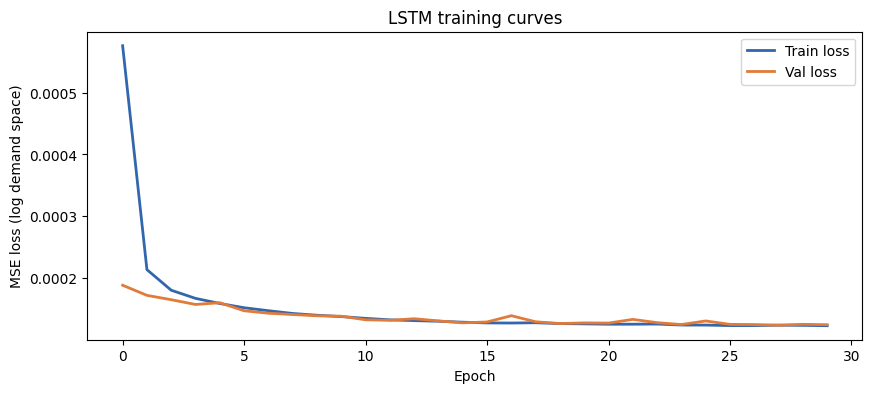

In [96]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["train_loss"], label="Train loss", color=PALETTE["primary"], lw=2)
ax.plot(history["val_loss"],   label="Val loss",   color=PALETTE["secondary"], lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss (log demand space)")
ax.set_title("LSTM training curves")
ax.legend()
plt.savefig("lstm_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
model_lstm.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        y_pred = model_lstm(X_batch.to(device)).cpu().numpy()
        all_preds.extend(y_pred)
        all_labels.extend(y_batch.numpy())

safe_preds_yeo = np.clip(np.array(all_preds), y_train.min(), y_train.max())

all_preds  = np.clip(
    pt_yeo.inverse_transform(safe_preds_yeo.reshape(-1, 1)).flatten(), 0, 1
)

all_labels = pt_yeo.inverse_transform(np.array(all_labels).reshape(-1, 1)).flatten()

score_lstm = competition_score(all_labels, all_preds)

ValueError: Input contains NaN.

In [ ]:
print("=" * 40)
print("  MODEL 4 — LSTM")
print("=" * 40)
print(f"  Val score: {score_lstm:.2f}")

  MODEL 4 — LSTM
  Val score: 86.83


In [99]:
results_summary = pd.DataFrame([
    {"Model": "Baseline (Ridge)",       "Val Score": score_val,       "Notes": "Linear, log1p target"},
    {"Model": "XGBoost",                "Val Score": score_xgb_val,   "Notes": "Tree ensemble, lag features"},
    {"Model": "LightGBM",               "Val Score": score_lgb_val,   "Notes": "Native categoricals"},
    {"Model": "Per-RoadType LightGBM",  "Val Score": score_combined,  "Notes": "Separate model per road type"},
    # {"Model": "LSTM",                   "Val Score": score_lstm,       "Notes": "Sequence model, sliding window"},
]).sort_values("Val Score", ascending=False)

print(results_summary.to_string(index=False))

                Model  Val Score                        Notes
Per-RoadType LightGBM    79.8144 Separate model per road type
             LightGBM    70.5920          Native categoricals
              XGBoost    66.7660  Tree ensemble, lag features
     Baseline (Ridge)    35.1800         Linear, log1p target


---
## **TEST PIPELINE**

In [100]:
lookback = (
    df_train.sort_values(["geohash", "day", "time_minutes"])
    .groupby("geohash")
    .tail(4)
    [["geohash", "day", "time_minutes", "demand"]]
    .copy()
)

In [101]:
print("Lookback table (last 4 training observations per geohash):")
print(lookback.head(12))
print(f"\nTotal lookback rows: {len(lookback):,}")

Lookback table (last 4 training observations per geohash):
   geohash  day  time_minutes  demand
4   qp02yc   48           450  0.0048
5   qp02yc   48           540  0.0174
6   qp02yc   48           630  0.0468
7   qp02yc   48           645  0.0212
30  qp02yz   48           705  0.0117
31  qp02yz   48           750  0.0255
32  qp02yz   48           900  0.0611
33  qp02yz   48           915  0.0396
50  qp02z1   48           495  0.0442
51  qp02z1   48           510  0.0087
52  qp02z1   48           735  0.0576
53  qp02z1   48           780  0.0012

Total lookback rows: 4,405


In [102]:
def compute_lags_with_lookback(df_test, df_train_lookback):
    """
    Compute lag features for the test set by prepending the last
    few training rows for each geohash as context.

    Parameters
    ----------
    df_test           : cleaned test dataframe (no demand column)
    df_train_lookback : last N rows of training per geohash

    Returns
    -------
    df_test with demand_lag1, demand_lag2, demand_lag4, demand_roll4_mean added
    """
    results = []

    for geo, group_test in df_test.groupby("geohash"):

        lookback_geo = df_train_lookback[df_train_lookback["geohash"] == geo].copy()

        if len(lookback_geo) == 0:
            group_test["demand_lag1"]      = np.nan
            group_test["demand_lag2"]      = np.nan
            group_test["demand_lag4"]      = np.nan
            group_test["demand_roll4_mean"] = np.nan
            results.append(group_test)
            continue

        lookback_geo["_is_lookback"] = True
        group_test["_is_lookback"]   = False

        if "demand" not in group_test.columns:
            group_test["demand"] = np.nan

        combined = pd.concat(
            [lookback_geo[["geohash","day","time_minutes","demand","_is_lookback"]],
             group_test],
            ignore_index=True
        ).sort_values("time_minutes")

        combined["demand_lag1"]       = combined["demand"].shift(1)
        combined["demand_lag2"]       = combined["demand"].shift(2)
        combined["demand_lag4"]       = combined["demand"].shift(4)
        combined["demand_roll4_mean"] = combined["demand"].shift(1).rolling(4, min_periods=1).mean()

        real_rows = combined[~combined["_is_lookback"]].copy()
        real_rows.drop(columns=["_is_lookback"], inplace=True)
        results.append(real_rows)

    return pd.concat(results, ignore_index=True)


In [103]:
df_test=pd.read_csv("test.csv")

In [104]:
train_geos = set(df_train["geohash"].unique())
test_geos  = set(df_test["geohash"].unique())
unseen = test_geos - train_geos
print(f"Unseen geohashes in test: {len(unseen)}")

Unseen geohashes in test: 81


In [105]:
def align_columns(df_test_encoded, train_columns):
    """
    Ensure df_test_encoded has exactly the same columns as the training matrix,
    in the same order. Missing columns are added as zeros. Extra columns are dropped.

    Parameters
    ----------
    df_test_encoded : test dataframe after one-hot encoding
    train_columns   : list of column names from the training feature matrix (FEATURES)

    Returns
    -------
    DataFrame with exactly train_columns, in that order
    """
    for col in train_columns:
        if col not in df_test_encoded.columns:
            print(f"  [WARNING] Column '{col}' missing from test — adding as zeros.")
            df_test_encoded[col] = 0

    extra_cols = set(df_test_encoded.columns) - set(train_columns)
    if extra_cols:
        print(f"  [INFO] Dropping {len(extra_cols)} extra test column(s): {extra_cols}")
        df_test_encoded.drop(columns=list(extra_cols), inplace=True)

    return df_test_encoded[train_columns]

In [106]:
sparse_geos = (
    df_train.groupby("geohash")["time_minutes"]
    .count()
    .rename("n_train_obs")
)

In [107]:
def safe_predict(model, X, pt_yeo, is_lgb=True):
    """Generate predictions clipped to valid demand range."""
    if is_lgb:
        yeo_preds = model.predict(X)
    else:
        # XGBoost
        yeo_preds = model.predict(X)

    raw_preds = pt_yeo.inverse_transform(yeo_preds.reshape(-1, 1)).flatten()
    clipped   = np.clip(raw_preds, 0.0, 1.0)

    n_below = (raw_preds < 0).sum()
    n_above = (raw_preds > 1).sum()
    if n_below > 0 or n_above > 0:
        print(f"  [INFO] Clipped {n_below} predictions below 0 and {n_above} above 1.")
        print(f"  If these numbers are large (>1% of rows), investigate model calibration.")

    return clipped

In [ ]:
def run_test_pipeline(test_path, df_train, geo_mean_map, geo5_time_mean, lgb_model, pt_yeo, FEATURES, known_cats, global_demand_mean):
    print("Step 1: Loading test data...")
    df_test = pd.read_csv(test_path)
    
    print("Step 2: Cleaning & Encoding...")
    res_train = df_train.get("RoadType_Residential", pd.Series(0, index=df_train.index)).astype(bool)
    str_train = df_train.get("RoadType_Street", pd.Series(0, index=df_train.index)).astype(bool)
    temp_roadtype = pd.Series("Highway", index=df_train.index) 
    temp_roadtype.loc[res_train] = "Residential"
    temp_roadtype.loc[str_train] = "Street"

    geo_roadtype_mode_train = temp_roadtype.groupby(df_train["geohash"]).agg(lambda x: x.mode()[0] if len(x) > 0 else np.nan)
    df_test["RoadType"] = df_test["RoadType"].fillna(df_test["geohash"].map(geo_roadtype_mode_train)).fillna("Highway")
    df_test["Weather"] = df_test["Weather"].fillna("Unknown")

    df_test["_hour_tmp"] = df_test["timestamp"].str.split(":").str[0].astype(int)
    geo_hour_temp_train  = df_train.groupby(["geohash", "hour"])["Temperature"].median()
    df_test["Temperature"] = df_test.apply(
        lambda r: geo_hour_temp_train.get((r["geohash"], r["_hour_tmp"]), np.nan) if pd.isnull(r.get("Temperature", np.nan)) else r.get("Temperature", np.nan), axis=1
    ).fillna(df_train["Temperature"].median())

    df_test["hour"]         = df_test["timestamp"].str.split(":").str[0].astype(int)
    df_test["minute"]       = df_test["timestamp"].str.split(":").str[1].astype(int)
    df_test["time_minutes"] = df_test["hour"] * 60 + df_test["minute"]
    PERIOD = 1440
    df_test["time_sin"] = np.sin(2 * np.pi * df_test["time_minutes"] / PERIOD)
    df_test["time_cos"] = np.cos(2 * np.pi * df_test["time_minutes"] / PERIOD)

    df_test["geohash_encoded"] = df_test["geohash"].map(geo_mean_map).fillna(global_demand_mean)
    df_test["geo5"] = df_test["geohash"].str[:5]
    df_test = df_test.merge(geo5_time_mean, on=["geo5", "time_minutes"], how="left")
    df_test["geo5_time_demand_mean"] = df_test["geo5_time_demand_mean"].fillna(global_demand_mean)

    df_test["LargeVehicles_enc"] = (df_test["LargeVehicles"] == "Allowed").astype(int)
    df_test["Landmarks_enc"]     = (df_test["Landmarks"] == "Yes").astype(int)
    df_test = pd.get_dummies(df_test, columns=["RoadType"], drop_first=True)
    df_test = pd.get_dummies(df_test, columns=["Weather"],  drop_first=True)

    X_test = align_columns(df_test.copy(), FEATURES)
    
    print("Step 3: Direct Stratified Prediction...")
    y_pred_lgb = np.zeros(len(df_test))
    
    res_mask = df_test.get("RoadType_Residential", pd.Series(0, index=df_test.index)).astype(bool)
    str_mask = df_test.get("RoadType_Street", pd.Series(0, index=df_test.index)).astype(bool)
    hwy_mask = ~(res_mask | str_mask)
    
    X_test_lgb = X_test.copy()
    X_test_lgb["geohash_cat"] = pd.Categorical(df_test["geohash"], categories=known_cats)
    X_test_lgb.drop(columns=["geohash_encoded"], inplace=True, errors='ignore')

    if "Highway" in lgb_model:
        idx = df_test.index[hwy_mask]
        if len(idx) > 0:
            y_pred_lgb[idx] = np.clip(pt_yeo.inverse_transform(lgb_model["Highway"].predict(X_test_lgb.loc[idx]).reshape(-1, 1)).flatten(), 0, 1)
    if "Street" in lgb_model:
        idx = df_test.index[str_mask]
        if len(idx) > 0:
            y_pred_lgb[idx] = np.clip(pt_yeo.inverse_transform(lgb_model["Street"].predict(X_test_lgb.loc[idx]).reshape(-1, 1)).flatten(), 0, 1)
    if "Residential" in lgb_model:
        idx = df_test.index[res_mask]
        if len(idx) > 0:
            y_pred_lgb[idx] = np.clip(pt_yeo.inverse_transform(lgb_model["Residential"].predict(X_test_lgb.loc[idx]).reshape(-1, 1)).flatten(), 0, 1)
            
    submission = pd.DataFrame({"Index": df_test["Index"], "demand": y_pred_lgb})
    submission.to_csv("submission.csv", index=False)
    print(f"  ✓ Saved submission.csv  ({len(submission):,} rows)")
    
    return submission

In [109]:
lookback = (
    df_train.sort_values(["geohash", "day", "time_minutes"])
    .groupby("geohash")
    .tail(4)
    [["geohash", "day", "time_minutes", "demand"]]
    .copy()
)


global_demand_mean = df_train["demand"].mean()
stats = df_train.groupby("geohash")["demand"].agg(["mean", "count"])
stats["encoded"] = (stats["count"] * stats["mean"] + 15 * global_demand_mean) / (stats["count"] + 15)
geo_mean_map = stats["encoded"].to_dict()

In [110]:
submission = run_test_pipeline(
    test_path          = "test.csv",
    df_train           = df_train,
    # lookback           = lookback,
    geo_mean_map       = geo_mean_map, 
    geo5_time_mean     = geo5_time_mean,
    lgb_model          = models_per_road,
    pt_yeo             = pt_yeo,
    FEATURES           = FEATURES,
    known_cats         = known_cats,
    global_demand_mean = global_demand_mean,
)

Step 1: Loading test data...
Step 2: Cleaning & Encoding...
  [INFO] Dropping 9 extra test column(s): {'Index', 'LargeVehicles', 'timestamp', '_hour_tmp', 'geohash', 'minute', 'day', 'geo5', 'Landmarks'}
Step 3: Direct Stratified Prediction...
  ✓ Saved submission_direct.csv  (41,778 rows)


In [112]:
sub = pd.read_csv("submission.csv")

print("Submission file audit:")
print(f"  Rows:    {len(sub):,}")
print(f"  Columns: {sub.columns.tolist()}")
print(f"  NaNs:    {sub.isnull().sum().values}")
print(f"  Min demand:  {sub['demand'].min():.6f}  (must be >= 0)")
print(f"  Max demand:  {sub['demand'].max():.6f}  (must be <= 1)")
print()
print(sub.head(10))

Submission file audit:
  Rows:    41,778
  Columns: ['Index', 'demand']
  NaNs:    [0 0]
  Min demand:  0.003662  (must be >= 0)
  Max demand:  0.791252  (must be <= 1)

   Index  demand
0      0  0.0291
1      1  0.0390
2      2  0.0893
3      3  0.0371
4      4  0.0307
5      5  0.0954
6      6  0.0229
7      7  0.0621
8      8  0.0277
9      9  0.0371


In [113]:
df_test_check = pd.read_csv("test.csv")

df_test_check["hour"] = df_test_check["timestamp"].str.split(":").str[0].astype(int)
df_test_check["minute"] = df_test_check["timestamp"].str.split(":").str[1].astype(int)
df_test_check["time_minutes"] = df_test_check["hour"] * 60 + df_test_check["minute"]

last_train_day = df_train['day'].max()
last_train_mins = df_train[df_train['day'] == last_train_day]['time_minutes'].max()
last_train_hr = last_train_mins // 60
last_train_m = last_train_mins % 60
print(f"END OF TRAIN:   Day {last_train_day} at {last_train_hr:02d}:{last_train_m:02d}")

first_test_day = df_test_check['day'].min()
first_test_mins = df_test_check[df_test_check['day'] == first_test_day]['time_minutes'].min()
first_test_hr = first_test_mins // 60
first_test_m = first_test_mins % 60
print(f"START OF TEST:  Day {first_test_day} at {first_test_hr:02d}:{first_test_m:02d}")

if first_test_day == last_train_day:
    gap_mins = first_test_mins - last_train_mins
    print(f"\nGap: {gap_mins} minutes")
else:
    days_between = (first_test_day - last_train_day - 1)
    mins_to_midnight = 1440 - last_train_mins
    total_gap_mins = mins_to_midnight + (days_between * 1440) + first_test_mins
    print(f"\nGap: {first_test_day - last_train_day} days and {total_gap_mins % 1440} minutes (Total: {total_gap_mins} minutes)")

END OF TRAIN:   Day 48 at 23:45
START OF TEST:  Day 49 at 02:15

Gap: 1 days and 150 minutes (Total: 150 minutes)
